In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [35]:
URL_CARS = "https://raw.githubusercontent.com/ammar-abdelhady/Car-Features-and-MSRP/main/data.csv"
df = pd.read_csv(URL_CARS)

print(df.shape)
df.head()

(11914, 16)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [37]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Market Category,3742,31.41
Engine HP,69,0.58
Engine Cylinders,30,0.25
Number of Doors,6,0.05
Engine Fuel Type,3,0.03


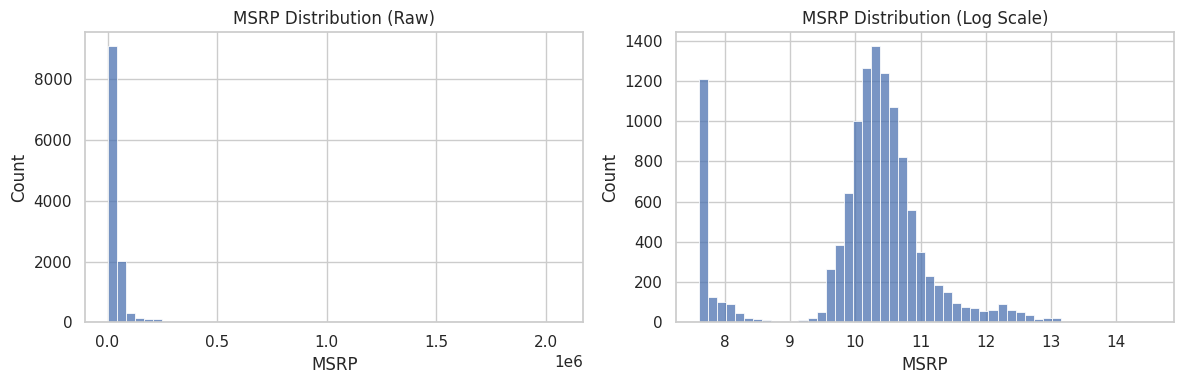

Skewness (raw): 11.77
Skewness (log): -0.92
count      11914.0
mean       40595.0
std        60109.0
min         2000.0
25%        21000.0
50%        29995.0
75%        42231.0
max      2065902.0


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["MSRP"], bins=50, ax=axes[0])
axes[0].set_title("MSRP Distribution (Raw)")

sns.histplot(np.log1p(df["MSRP"]), bins=50, ax=axes[1])
axes[1].set_title("MSRP Distribution (Log Scale)")

plt.tight_layout()
plt.show()

print(f"Skewness (raw): {df['MSRP'].skew():.2f}")
print(f"Skewness (log): {np.log1p(df['MSRP']).skew():.2f}")
print(df["MSRP"].describe().round(0).to_string())

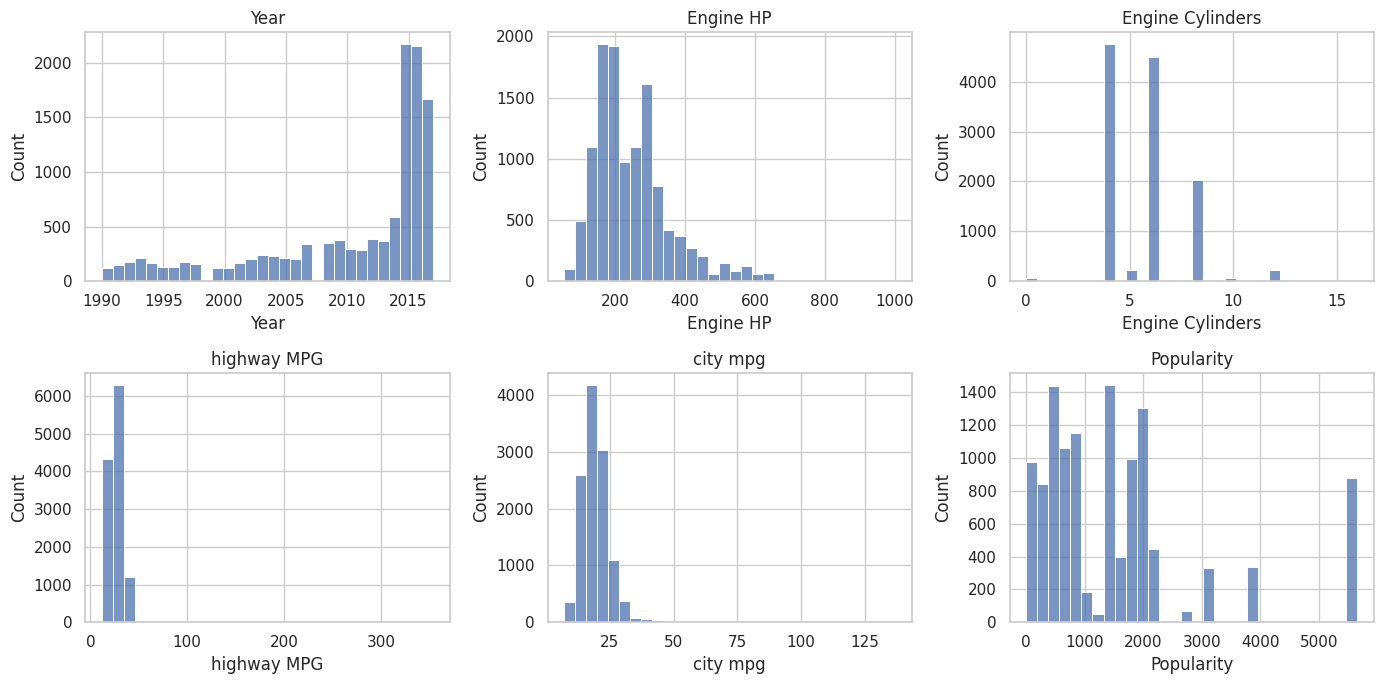

In [39]:
num_cols = ["Year", "Engine HP", "Engine Cylinders", "highway MPG", "city mpg", "Popularity"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

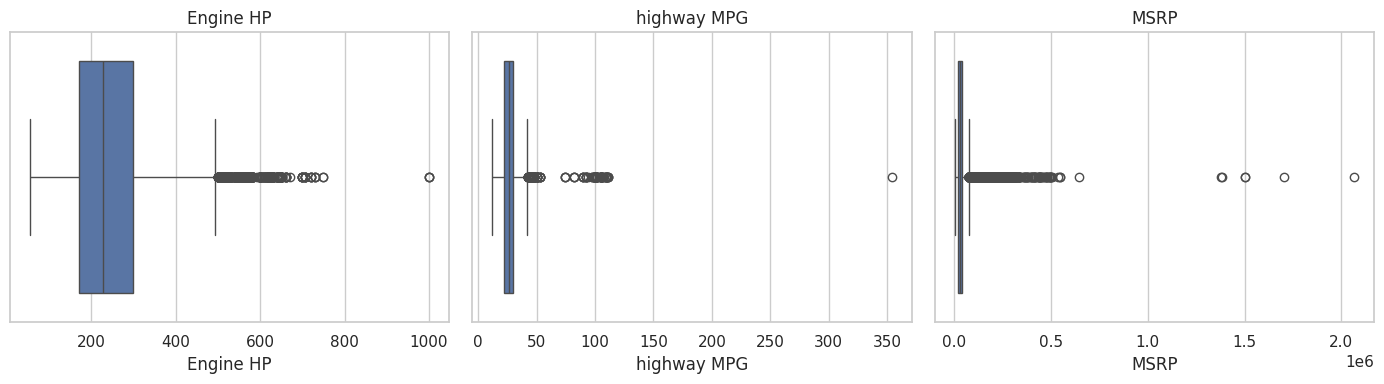

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Engine HP", "highway MPG", "MSRP"]):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

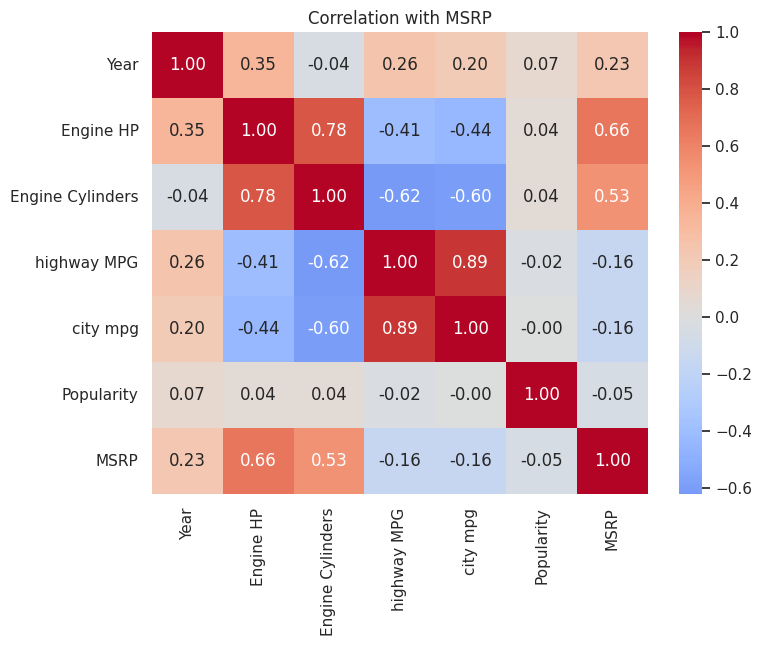

In [41]:
corr = df[num_cols + ["MSRP"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation with MSRP")
plt.show()

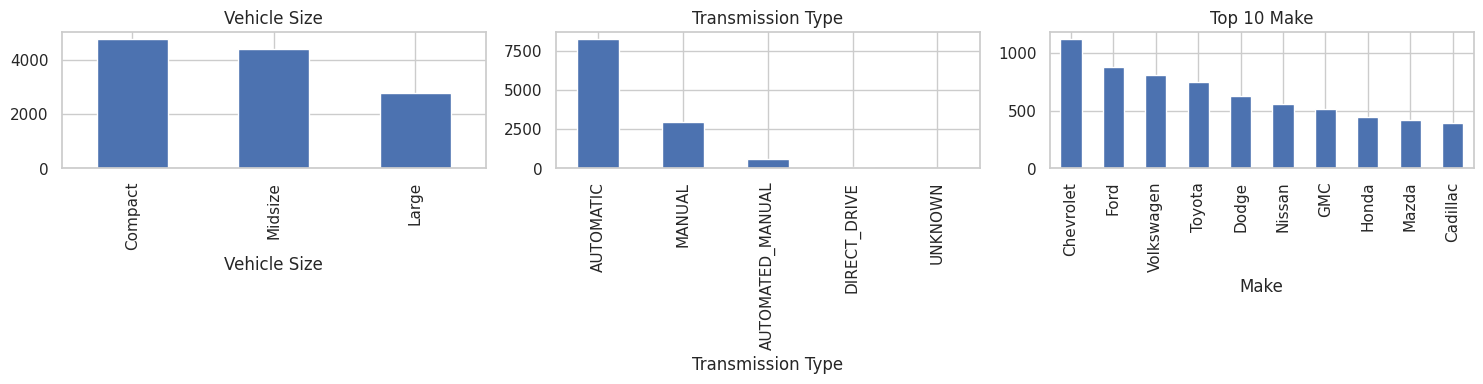

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["Vehicle Size"].value_counts().plot(kind="bar", ax=axes[0], title="Vehicle Size")
df["Transmission Type"].value_counts().plot(kind="bar", ax=axes[1], title="Transmission Type")
df["Make"].value_counts().head(10).plot(kind="bar", ax=axes[2], title="Top 10 Make")

plt.tight_layout()
plt.show()

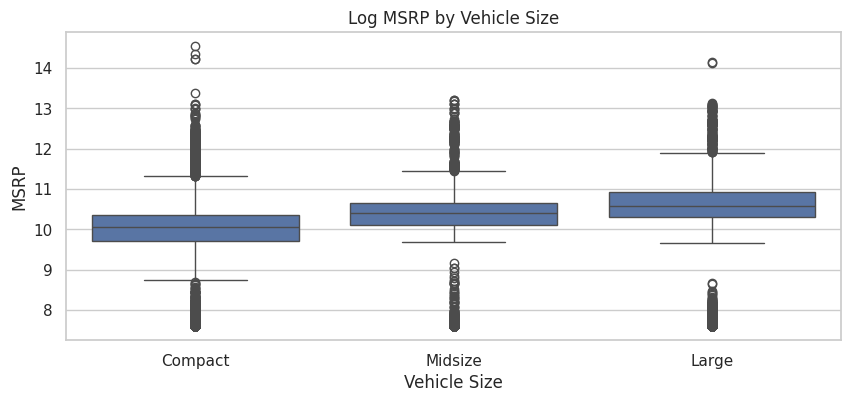

Vehicle Size
Large      39380.0
Midsize    32785.0
Compact    23580.0


In [43]:
plt.figure(figsize=(10, 4))
order = df.groupby("Vehicle Size")["MSRP"].median().sort_values().index
sns.boxplot(data=df, x="Vehicle Size", y=np.log1p(df["MSRP"]), order=order)
plt.title("Log MSRP by Vehicle Size")
plt.show()

print(df.groupby("Vehicle Size")["MSRP"].median().sort_values(ascending=False).round(0).to_string())

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Baseline: numeric features only, median imputation, no engineering
baseline_features = ["Year", "Engine HP", "Engine Cylinders",
                     "Number of Doors", "highway MPG", "city mpg", "Popularity"]

X_base = df[baseline_features].fillna(df[baseline_features].median())
y_base = df["MSRP"]

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
pred_base = rf_base.predict(X_test)

mae_base = mean_absolute_error(y_test, pred_base)
r2_base = r2_score(y_test, pred_base)
print(f"BASELINE  ->  MAE: ${mae_base:,.0f} | R2: {r2_base:.4f}")

BASELINE  ->  MAE: $3,884 | R2: 0.9400


In [45]:
df_fe = df.copy()

# 1. Fix data error found in EDA (impossible MPG value)
df_fe.loc[df_fe["highway MPG"] > 100, "highway MPG"] = np.nan

# 2. Derived features
df_fe["Car_Age"] = 2026 - df_fe["Year"]
df_fe["Avg_MPG"] = (df_fe["highway MPG"] + df_fe["city mpg"]) / 2   # merge redundant pair
df_fe["HP_per_Cylinder"] = np.where(
    df_fe["Engine Cylinders"] > 0,
    df_fe["Engine HP"] / df_fe["Engine Cylinders"],
    np.nan   # electric cars (0 cylinders) -> NaN, imputed later
)

# 3. Market Category (31% missing): missing is a signal -> flag + count
df_fe["Has_Market_Category"] = df_fe["Market Category"].notna().astype(int)
df_fe["Num_Categories"] = df_fe["Market Category"].fillna("").apply(
    lambda x: len(x.split(",")) if x else 0
)
df_fe["Is_Luxury"] = df_fe["Market Category"].fillna("").str.contains("Luxury").astype(int)
df_fe["Is_Performance"] = df_fe["Market Category"].fillna("").str.contains("Performance").astype(int)

# 4. Encode categoricals (one-hot for low-cardinality)
df_fe = pd.get_dummies(
    df_fe,
    columns=["Vehicle Size", "Vehicle Style", "Transmission Type",
             "Driven_Wheels", "Engine Fuel Type"],
    drop_first=True
)
# 5. Make: high-cardinality (48 brands) -> frequency encoding
make_freq = df_fe["Make"].value_counts(normalize=True)
df_fe["Make_Freq"] = df_fe["Make"].map(make_freq)

# 6. Drop unused / weak columns (Popularity ~0 correlation from EDA)
df_fe = df_fe.drop(columns=["Make", "Model", "Market Category", "Popularity", "Year"])

print(df_fe.shape)
df_fe.head(3)

(11914, 47)


,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,MSRP,Car_Age,Avg_MPG,HP_per_Cylinder,Has_Market_Category,Num_Categories,Is_Luxury,Is_Performance,Vehicle Size_Large,Vehicle Size_Midsize,Vehicle Style_2dr SUV,Vehicle Style_4dr Hatchback,Vehicle Style_4dr SUV,Vehicle Style_Cargo Minivan,Vehicle Style_Cargo Van,Vehicle Style_Convertible,Vehicle Style_Convertible SUV,Vehicle Style_Coupe,Vehicle Style_Crew Cab Pickup,Vehicle Style_Extended Cab Pickup,Vehicle Style_Passenger Minivan,Vehicle Style_Passenger Van,Vehicle Style_Regular Cab Pickup,Vehicle Style_Sedan,Vehicle Style_Wagon,Transmission Type_AUTOMATIC,Transmission Type_DIRECT_DRIVE,Transmission Type_MANUAL,Transmission Type_UNKNOWN,Driven_Wheels_four wheel drive,Driven_Wheels_front wheel drive,Driven_Wheels_rear wheel drive,Engine Fuel Type_electric,Engine Fuel Type_flex-fuel (premium unleaded recommended/E85),Engine Fuel Type_flex-fuel (premium unleaded required/E85),Engine Fuel Type_flex-fuel (unleaded/E85),Engine Fuel Type_flex-fuel (unleaded/natural gas),Engine Fuel Type_natural gas,Engine Fuel Type_premium unleaded (recommended),Engine Fuel Type_premium unleaded (required),Engine Fuel Type_regular unleaded,Make_Freq
0,335.0,6.0,2.0,26.0,19,46135,15,22.5,55.833333,1,3,1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,0.028034
1,300.0,6.0,2.0,28.0,19,40650,15,23.5,50.000000,1,2,1,1,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,0.028034
2,300.0,6.0,2.0,28.0,20,36350,15,24.0,50.000000,1,2,1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,0.028034


In [46]:
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
X_fe = df_fe.drop(columns=["MSRP"]).fillna(df_fe.drop(columns=["MSRP"]).median(numeric_only=True))

X_fe = df_fe.drop(columns=["MSRP"]).fillna(df_fe.drop(columns=["MSRP"]).median())
y_fe = np.log1p(df_fe["MSRP"])   # log-transform, justified by EDA

X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

rf_fe = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_fe.fit(X_train, y_train)

# Convert predictions back to dollars for a fair comparison
pred_fe = np.expm1(rf_fe.predict(X_test))
y_test_dollar = np.expm1(y_test)

mae_fe = mean_absolute_error(y_test_dollar, pred_fe)
r2_fe = r2_score(y_test_dollar, pred_fe)
print(f"ENGINEERED  ->  MAE: ${mae_fe:,.0f} | R2: {r2_fe:.4f}")

ENGINEERED  ->  MAE: $3,067 | R2: 0.9739


In [47]:
comparison = pd.DataFrame({
    "Model": ["Baseline (raw numeric)", "With Feature Engineering"],
    "Features": [X_base.shape[1], X_fe.shape[1]],
    "MAE ($)": [round(mae_base), round(mae_fe)],
    "R2": [round(r2_base, 4), round(r2_fe, 4)],
})
comparison["Improvement"] = ["-", f"MAE turun {(1 - mae_fe/mae_base)*100:.1f}%"]
comparison

,Model,Features,MAE ($),R2,Improvement
0,Baseline (raw numeric),7,3884,0.9400,-
1,With Feature Engineering,46,3067,0.9739,MAE turun 21.0%


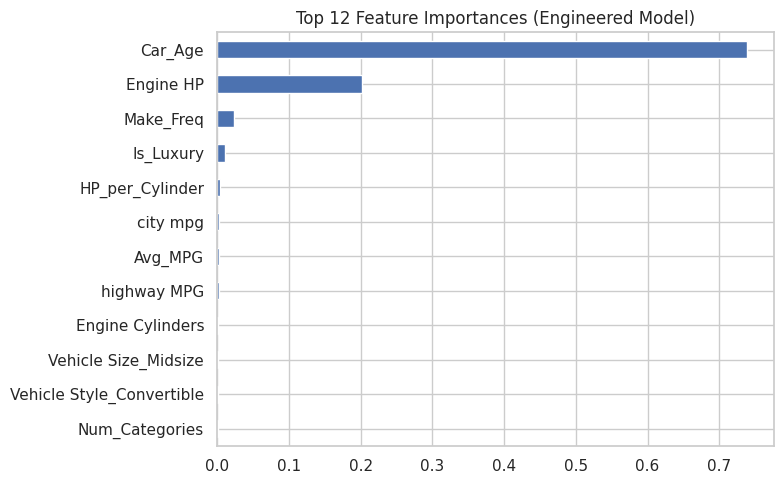

In [48]:
importances = pd.Series(rf_fe.feature_importances_, index=X_fe.columns)
importances.nlargest(12).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 12 Feature Importances (Engineered Model)")
plt.tight_layout()
plt.show()